# EfficientNet-B0 — Entropy Filtering, Ordinal Focal Regression Loss

This notebook trains an EfficientNet-B0 model with:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal Focal Regression Loss**: Combines focal loss (replacing BCE) with the ordinal MSE penalty

The loss has two terms:
1. **Focal loss** — replaces plain BCE, down-weighting easy examples: `FL = -alpha * (1-p_t)^gamma * log(p_t)`
2. **Ordinal MSE** — penalises distance between predicted and true expected grade: `(E[pred] - E[true])^2 / C^2`

Total loss: `L = alpha_w * FocalLoss + beta_w * OrdinalMSE`

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../../../')
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [ ]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor
focal_gamma = 0.2   # Focusing parameter

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal-regression.pth'
log_path = 'logs/b0-entropy-ordinal-focal-regression.txt'

Using device: cuda


## Ordinal Focal Regression Loss

Replaces the plain BCE in `OrdinalRegressionLoss` with **focal loss**, keeping the ordinal MSE term:

```
FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
OrdinalMSE = mean((sum(sigmoid(z)) - sum(y))^2) / C^2

L = alpha_w * FL + beta_w * OrdinalMSE
```

- **Focal term**: handles class imbalance and focuses on hard threshold decisions
- **Ordinal MSE term**: enforces that the *expected* predicted grade stays close to the true grade

In [3]:
import torch.nn.functional as F

class OrdinalFocalRegressionLoss(nn.Module):
    """
    Ordinal Regression Loss with Focal Loss replacing plain BCE.

    Loss = alpha_w * FocalLoss + beta_w * OrdinalMSE

    FocalLoss:
        FL(p_t) = -alpha * (1 - p_t)^gamma * BCE(logits, targets)
        Focuses training on hard threshold decisions and handles class imbalance.

    OrdinalMSE:
        Penalises the squared distance between the expected predicted grade
        (sum of sigmoid probabilities) and the true grade (sum of ordinal labels),
        normalised by C^2 to keep the scale comparable to the focal term.
    """
    def __init__(self, alpha=0.25, gamma=2.0, alpha_w=1.0, beta_w=1.0):
        super().__init__()
        self.alpha   = alpha    # focal weighting factor
        self.gamma   = gamma    # focal focusing parameter
        self.alpha_w = alpha_w  # weight for focal term
        self.beta_w  = beta_w   # weight for ordinal MSE term

    def forward(self, logits, targets):
        targets = targets.to(logits.device)
        probs   = torch.sigmoid(logits)

        bce_loss     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t          = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        focal_loss   = (self.alpha * focal_weight * bce_loss).mean()

        # Ordinal MSE term
        expected_class = probs.sum(dim=1)
        targets_class  = targets.sum(dim=1)
        max_class      = logits.shape[1]
        ordinal_loss   = torch.mean((expected_class - targets_class) ** 2) / (max_class ** 2)

        return self.alpha_w * focal_loss + self.beta_w * ordinal_loss


loss_function = OrdinalFocalRegressionLoss(
    alpha=focal_alpha,
    gamma=focal_gamma,
    alpha_w=1.0,
    beta_w=1.0,
)
print("Ordinal Focal Regression Loss initialized")
print(f"  focal_alpha : {focal_alpha}")
print(f"  focal_gamma : {focal_gamma}")
print( "  alpha_w (focal weight)   : 1.0")
print( "  beta_w  (ordinal weight) : 1.0")


def decode_ordinal_predictions(logits):
    probs = torch.sigmoid(logits)
    return (probs > 0.5).sum(dim=1)


Ordinal Focal Regression Loss initialized
  focal_alpha : 0.25
  focal_gamma : 2.0
  alpha_w (focal weight)   : 1.0
  beta_w  (ordinal weight) : 1.0


## Load Data with Entropy Filtering

In [4]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

print(df_entropy_sorted.head())
n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)

# Maneira Correta
print("max_entropy", df_entropy_top["isup_grade"].value_counts())
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
                           image_id data_provider  isup_grade gleason_score  \
0  e0f8b96960ada384a00e493545f783da       radboud           5           5+5   
1  c3f6dfc5c801b1f2aed4c9e318bd015d       radboud           5           5+5   
2  35c7912e941c9bf21594deeda6c891e2       radboud           3           4+3   
3  a4514f8a6800bf122ae746c4f573ee6f       radboud           5           5+5   
4  0a8c2bda6e00a040372185ccd9a3c4ab    karolinska           5           4+5   

   fold             image_id_from_results  true_label  pred_b0  entropy_b0  \
0     1  e0f8b96960ada384a00e493545f783da         5.0      3.0    0.646624   
1     2  c3f6dfc5c801b1f2aed4c9e318bd015d         5.0      0.0    0.114379   
2     0  35c7912e941c9bf21594deeda6c891e2         3.0      4.0         NaN   
3     0  a4514f8a6800bf122ae746c4f573ee6f         5.0      4.0    0.327839   
4     0  0a8c2bda6e00a040372185ccd9a3c4ab         5.0      4.0    0.319212  

## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2358
Validation batches: 589
Test batches: 530


## Model Setup

In [7]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            probs = torch.sigmoid   (logits)
            predictions = (probs > 0.5).sum(dim=1)

            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [10]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  ✓ Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:32<00:00,  6.40it/s]



Results:
  Train Loss: 0.09751
  Val Loss: 0.06187
  Val Accuracy: 57.16%
  Val Kappa: 0.7938
  Val F1: 0.5077
  Learning Rate: 0.0003000

  ✓ Best model saved! Kappa: 0.7938

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:35<00:00,  6.20it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.07912
  Val Loss: 0.07182
  Val Accuracy: 53.82%
  Val Kappa: 0.7562
  Val F1: 0.4368
  Learning Rate: 0.0003003

  No improvement for 1 epoch(s)

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.03128
  Val Loss: 0.05557
  Val Accuracy: 65.48%
  Val Kappa: 0.8534
  Val F1: 0.5641
  Learning Rate: 0.0001929

  No improvement for 5 epoch(s)

Epoch 23/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:47<00:00,  5.49it/s]



Results:
  Train Loss: 0.03012
  Val Loss: 0.05525
  Val Accuracy: 66.67%
  Val Kappa: 0.8535
  Val F1: 0.5794
  Learning Rate: 0.0001836

  No improvement for 6 epoch(s)

Epoch 24/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:47<00:00,  5.50it/s]


Results:
  Train Loss: 0.02972
  Val Loss: 0.05058
  Val Accuracy: 64.63%
  Val Kappa: 0.8586
  Val F1: 0.5785
  Learning Rate: 0.0001741

  No improvement for 7 epoch(s)

Early stopping at epoch 24
Best epoch: 17 with Kappa: 0.8601

Training completed!
Best validation Kappa: 0.8601 at epoch 17


## Plot Training History

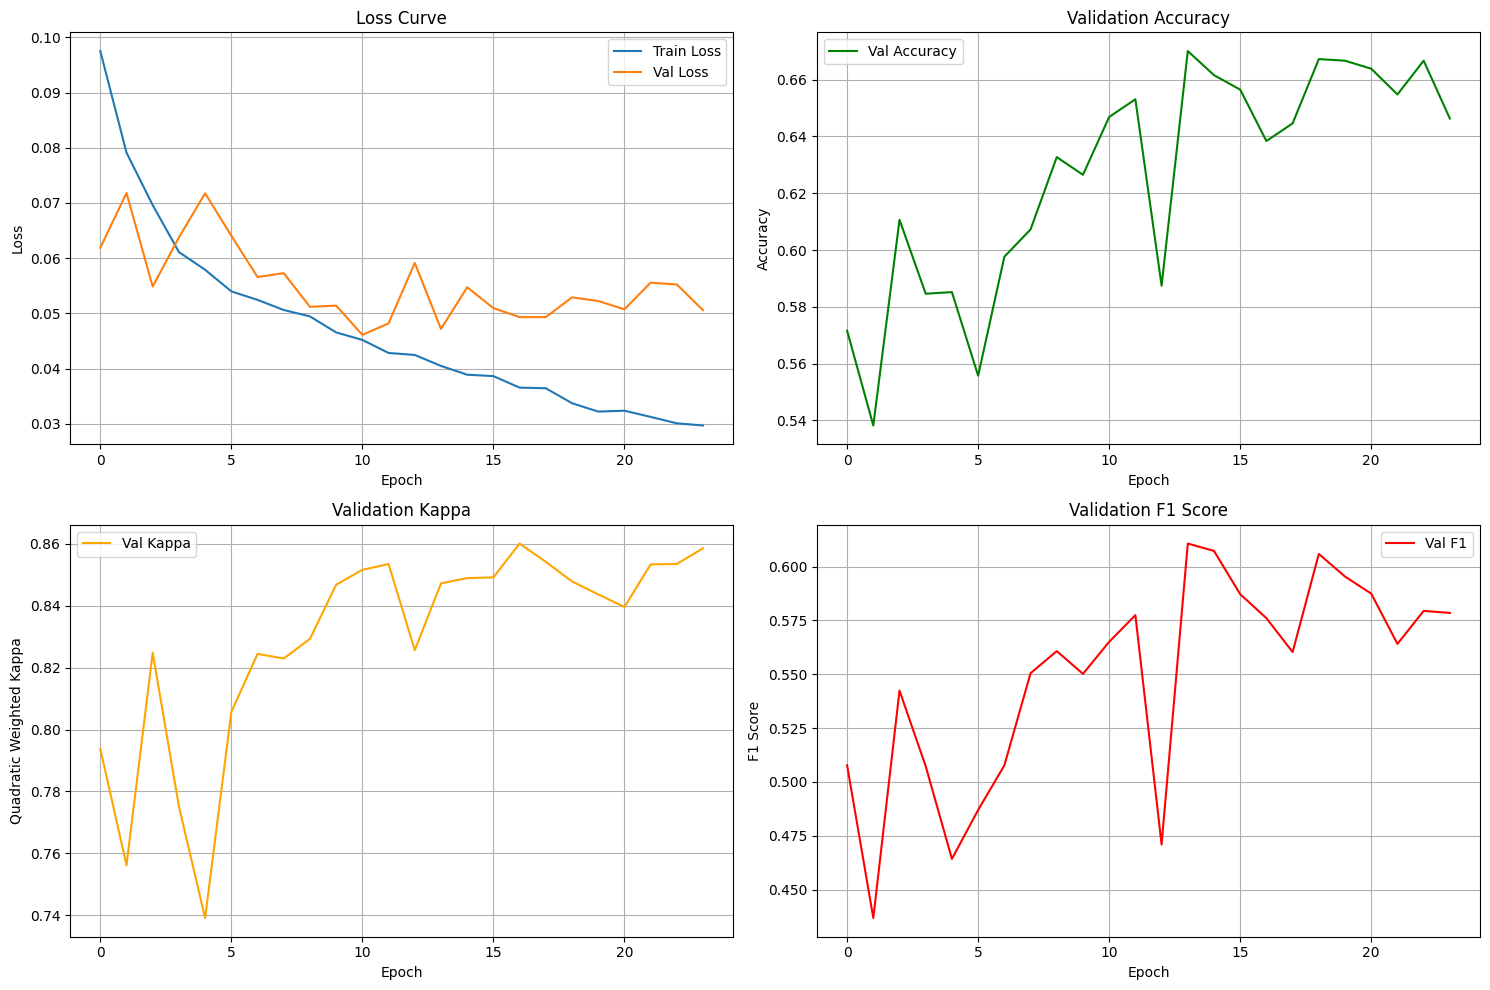

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-regression-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

In [12]:
from utils.metrics import evaluation, format_metrics

# from sklearn.metrics import classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt
#
# # Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
# model.eval()
#
# # Evaluate on test set
# test_preds = []
# test_targets = []
#
# print("Evaluating on test set...\n")
#
# with torch.no_grad():
#     for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
#         batch_data = batch_data.to(device)
#
#         # Forward pass
#         logits = model(batch_data)
#
#         # Decode predictions
#         predictions = decode_ordinal_predictions(logits)
#
#         # Convert ordinal targets to class labels
#         targets_class = batch_targets.sum(dim=1).long()
#
#         test_preds.append(predictions.cpu())
#         test_targets.append(targets_class)
#
# # Concatenate results
# test_preds = torch.cat(test_preds).numpy()
# test_targets = torch.cat(test_targets).numpy()
#
# # Calculate metrics
# test_accuracy = accuracy_score(test_targets, test_preds)
# test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
# test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)
#
# print("\n" + "="*80)
# print("TEST SET RESULTS")
# print("="*80)
# print(f"Accuracy: {test_accuracy*100:.2f}%")
# print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
# print(f"Macro F1 Score: {test_f1:.4f}")
# print("="*80)
#
# # Classification report
# print("\nClassification Report:")
# print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
#
# # Confusion matrix
# cm = confusion_matrix(test_targets, test_preds)
# print("\nConfusion Matrix:")
# print(cm)
#
# # Plot confusion matrix
# plt.figure(figsize=(10, 8))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt='d',
#     cmap='Blues',
#     xticklabels=[f'ISUP {i}' for i in range(6)],
#     yticklabels=[f'ISUP {i}' for i in range(6)],
#     cbar_kws={'label': 'Count'}
# )
# plt.title('Confusion Matrix - Test Set (Ordinal Loss)', fontsize=14, fontweight='bold')
# plt.ylabel('True Label', fontsize=12)
# plt.xlabel('Predicted Label', fontsize=12)
# plt.tight_layout()
# plt.savefig('logs/b0-entropy-ordinal-confusion-matrix.png', dpi=300, bbox_inches='tight')
# plt.show()
#
# # Save test results
# with open('../logs/b0-entropy-ordinal-test-results.txt', 'w') as f:
#     f.write("EfficientNet-B0 with Entropy Filtering and Ordinal Loss\n")
#     f.write("="*80 + "\n\n")
#     f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
#     f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
#     f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
#     f.write("Classification Report:\n")
#     f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
#     f.write("\nConfusion Matrix:\n")
#     f.write(str(cm))
#
# print("\nTest results saved to logs/b0-entropy-ordinal-test-results.txt")
response = evaluation(model, test_loader, device)
result = format_metrics(response[0])
print("\n=== TEST RESULTS (ENTROPY ORDINAL=2.0) ===")
print(result)

100%|██████████| 530/530 [01:24<00:00,  6.26it/s]



=== TEST RESULTS (ENTROPY ORDINAL=2.0) ===
VAL_ACC      Mean: 0.529 | Std: 0.013 | 95% CI: [0.508, 0.549]
VAL_KAPPA    Mean: 0.843 | Std: 0.009 | 95% CI: [0.826, 0.857]
VAL_F1       Mean: 0.504 | Std: 0.012 | 95% CI: [0.484, 0.525]
VAL_RECALL   Mean: 0.505 | Std: 0.013 | 95% CI: [0.484, 0.526]
VAL_PRECISION Mean: 0.548 | Std: 0.011 | 95% CI: [0.530, 0.566]
MEAN_ERROR   Mean: 0.577 | Std: 0.018 | 95% CI: [0.548, 0.607]


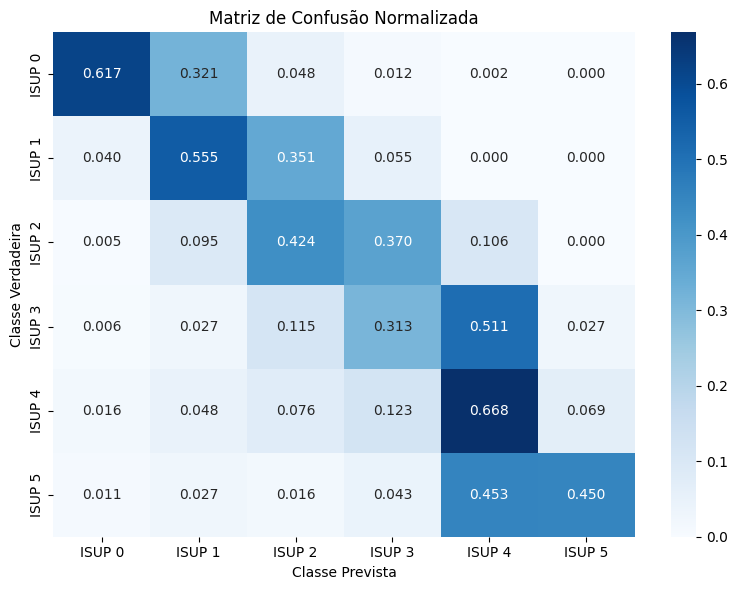

In [13]:
cm = response[0].get("confusion_matrix")
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalização por linha (cada linha soma 1)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels das classes (ajuste conforme necessário)
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Matriz de Confusão Normalizada")
plt.ylabel("Classe Verdadeira")
plt.xlabel("Classe Prevista")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-regression-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()


## Summary

This notebook trained EfficientNet-B0 with:
1. **Entropy filtering** — Removed top 20% high-entropy samples for cleaner training data
2. **Ordinal Focal Regression Loss** — Combines two complementary terms:
   - **Focal loss** replaces plain BCE to handle class imbalance and focus on hard examples
   - **Ordinal MSE** penalises grade-level distance, reinforcing ordinal structure

### How the combined loss works

| Term | Formula | Role |
|---|---|---|
| Focal | `-alpha*(1-p_t)^gamma * log(p_t)` | Hard example mining + class balance |
| Ordinal MSE | `(E[pred]-E[true])^2 / C^2` | Enforces ordinal grade ordering |

Compared to `b0-entropy-ordinal-3` (plain BCE + ordinal MSE), the focal term reduces the influence of easy, well-classified thresholds and makes the model focus on the boundary decisions that are hardest to learn.